# Análisis Exploratorio de Datos (EDA)  
## IRAG — Detección de comportamiento epidémico inusual

Este cuaderno desarrolla la fase de **Análisis Exploratorio de Datos (EDA)** y la comprensión del conjunto de datos utilizado en el proyecto de modelado IRAG.

Los objetivos principales de este EDA son:

- Describir la estructura del conjunto de datos (dimensiones y tipos de variables).
- Verificar la calidad de los datos (valores faltantes, rangos y consistencia).
- Explorar descriptivamente los principales indicadores de IRAG (hospitalización, UCI, mortalidad y consultas).
- Analizar la distribución de la variable objetivo (`target`), que indica si en una semana se observa un comportamiento **normal (0)** o **inusual (1)**.
- Producir insumos para la fase de modelado supervisado.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

# Cargar dataset limpio generado por DVC
df = pd.read_csv("../data/clean/train.csv")

df.head()

,anio,semana,HOSPITALIZACION IRAG MENOR 1 AÑO,HOSPITALIZACION IRAG 1 AÑO,HOSPITALIZACION IRAG 2 A 4 AÑOS,HOSPITALIZACION IRAG 5 A 19 AÑOS,HOSPITALIZACION IRAG 20 A 39 AÑOS,HOSPITALIZACION IRAG 40 A 59 AÑOS,HOSPITALIZACION IRAG MAYOR 60 AÑOS,TOTAL CASOS DE HOSPITALIZACIONES POR IRAG,TOTAL CAUSAS HOSPITALIZACIONES MENOR 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 2 A 4 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 5 A 19 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 20 A 39 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 40 A 59 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES MAYOR 60 AÑOS,TOTAL HOSPITALIZACIONES POR TODAS LAS CAUSAS,HOSPITALIZACIONES EN UCI POR IRAG MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG MAYOR 60 AÑOS,TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MAYOR 60 AÑOS,TOTAL TODAS LAS HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS,MUERTES POR IRAG MENOR 1 AÑO,MUERTES POR IRAG 1 AÑO,MUERTES POR IRAG 2 A 4 AÑOS,MUERTES POR IRAG 5 A 19 AÑOS,MUERTES POR IRAG 20 A 39 AÑOS,MUERTES POR IRAG 40 A 59 AÑOS,MUERTES POR IRAG MAYOR 60 AÑOS,TOTAL DE MUERTES POR IRAG,TODAS LAS CAUSAS DE MUERTE MENOR 1 AÑO,TODAS LAS CAUSAS DE MUERTE 1 AÑO,TODAS LAS CAUSAS DE MUERTE 2 A 4 AÑOS,TODAS LAS CAUSAS DE MUERTE 5 A 19 AÑOS,TODAS LAS CAUSAS DE MUERTE 20 A 39 AÑOS,TODAS LAS CAUSAS DE MUERTE 40 A 59 AÑOS,TODAS LAS CAUSAS DE MUERTE MAYOR 60 AÑOS,TOTAL DE MUERTES POR TODAS LAS CAUSAS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MENOR 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 2 A 4 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 5 A 19 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 20 A 39 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 40 A 59 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MENOR 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 2 A 4 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 5 A 19 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 20 A 39 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 40 A 59 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO EL IRAG,prop_hosp_irag,prop_uci_irag,prop_muertes_irag,prop_consultas_irag,I_t_minus_1,growth_rate,target
0,2012,2,7,3,9,3,0,1,0,23,6,2,8,0,0,0,0,16,6,2,8,0,0,0,0,16,2,1,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,23,49,88,81,48,11,306,23,47,137,221,250,182,160,1020,1.352941,4.000000,0.000000,0.299706,0.000000,1.352941,1
1,2012,3,3,3,5,5,0,1,3,20,4,3,6,18,30,9,97,167,4,3,6,18,30,9,97,167,4,0,0,0,2,5,21,32,0,0,0,0,0,1,2,3,1,0,0,0,0,2,10,13,12,26,25,54,104,56,41,318,77,101,226,583,1044,951,1082,4064,0.119048,5.060606,0.214286,0.078229,1.352941,-0.524405,0
2,2012,4,4,4,4,7,1,1,19,40,16,23,28,67,166,115,149,564,16,23,28,67,166,115,149,564,17,2,1,2,0,3,18,43,0,0,0,0,0,0,2,2,1,0,0,1,0,2,19,23,26,50,40,106,149,94,56,521,166,237,493,1241,2079,1881,1695,7792,0.070796,12.818182,0.083333,0.066855,0.119048,-0.043118,0
3,2012,5,3,1,1,3,15,26,13,62,2,3,3,21,72,62,94,257,2,3,3,21,72,62,94,257,10,0,0,2,5,2,17,36,0,0,0,0,0,0,0,0,1,0,0,1,0,2,7,1

## 1. Carga del dataset e información general

Se carga el dataset limpio generado en las etapas previas (clean_data y prepare_data) y se revisa:

- Número de filas (registros semanales).

- Número de columnas (indicadores y proporciones).

- Tipos de datos.

- Presencia de valores nulos.

Esto permite validar que la fase de limpieza se ejecutó correctamente.

In [ ]:
df.info()

## 2. Estadísticas descriptivas de las variables numéricas

Se calculan estadísticas básicas (media, desviación estándar, mínimos, máximos y cuartiles) para las variables numéricas.

Estas estadísticas permiten:

- Identificar rangos típicos de hospitalización, UCI, mortalidad y consultas.

- Detectar valores atípicos.

- Identificar variables con baja variabilidad.

In [ ]:
df.describe().T

## 3. Análisis de valores faltantes

3. Análisis de valores faltantes

Se calcula el número de valores nulos por columna. Con base en estos valores se evaluará si es necesario: Imputar datos, Eliminar registros, o descartar variables con alto nivel de faltantes.

In [50]:
df.isna().sum()

anio                                0
semana                              0
HOSPITALIZACION IRAG MENOR 1 AÑO    0
HOSPITALIZACION IRAG 1 AÑO          0
HOSPITALIZACION IRAG 2 A 4 AÑOS     0
                                   ..
prop_muertes_irag                   0
prop_consultas_irag                 0
I_t_minus_1                         0
growth_rate                         0
target                              0
Length: 73, dtype: int64

## 4. Distribución de la variable objetivo (target)

La variable target codifica el comportamiento semanal del IRAG:

- 0: semana con comportamiento normal.

- 1: comportamiento inusual.

Se revisa su distribución para identificar potencial desbalance entre clases.

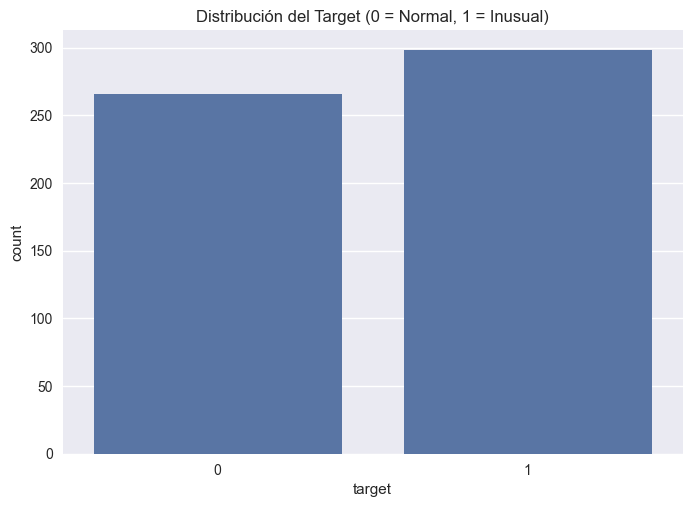

target
1    0.528369
0    0.471631
Name: proportion, dtype: float64

In [51]:
sns.countplot(x=df["target"])
plt.title("Distribución del Target (0 = Normal, 1 = Inusual)")
plt.show()

df["target"].value_counts(normalize=True)

## 5. Matriz de correlación entre variables numéricas

Se calcula una matriz de correlación de Pearson para entender relaciones entre indicadores.

Esto permite:

- Identificar grupos de variables correlacionadas.

- Detectar redundancias.

Evaluar correlaciones relevantes respecto a target.

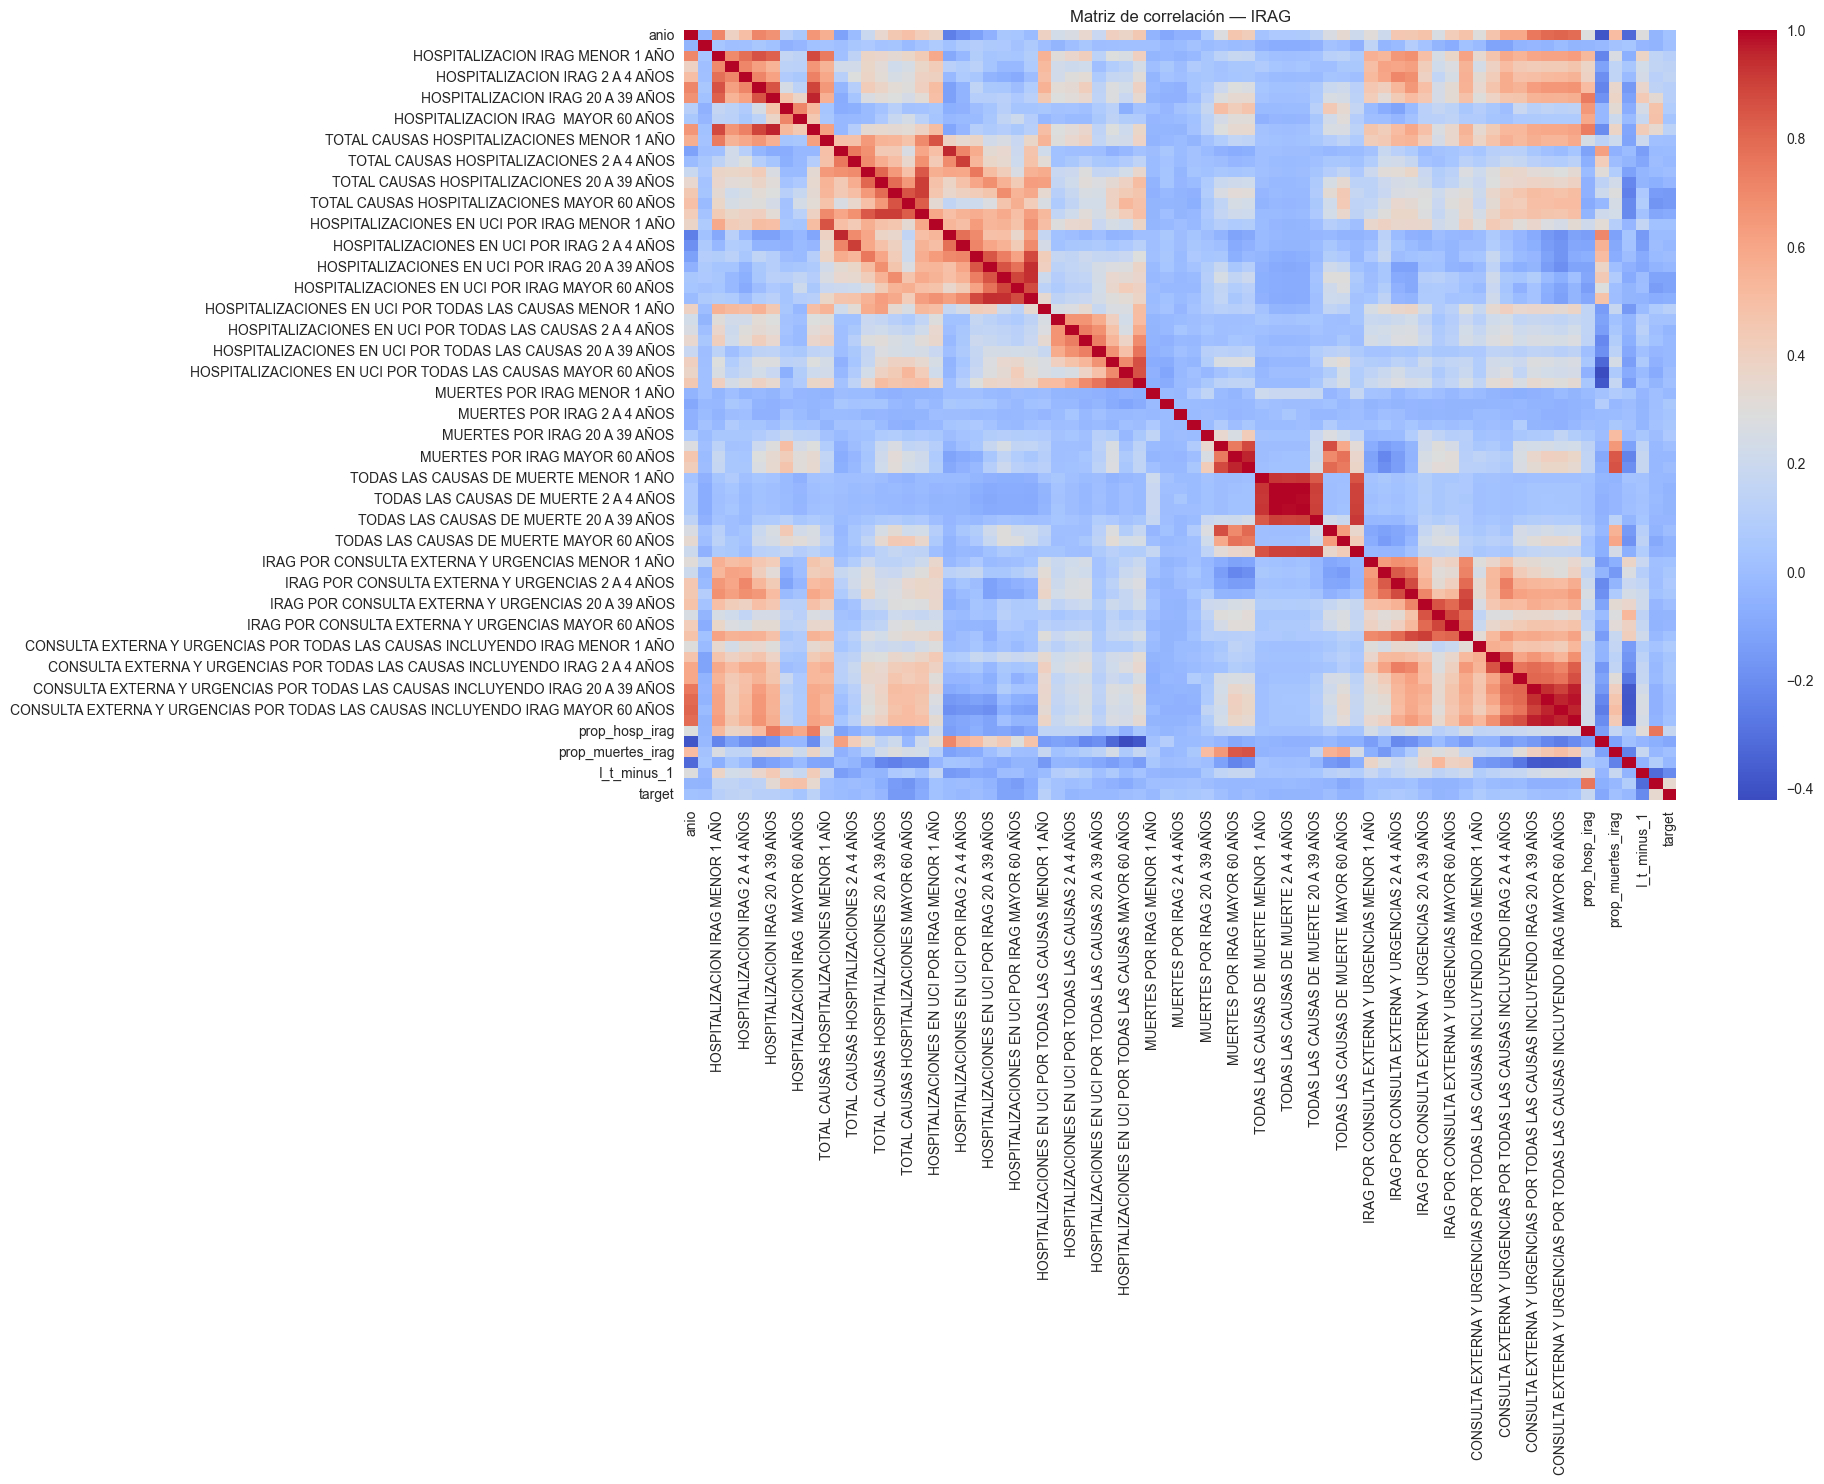

In [52]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Matriz de correlación — IRAG")
plt.show()

6. Tendencias temporales del IRAG

- Se analiza la evolución temporal de las hospitalizaciones por IRAG por semana epidemiológica y año.

- Este análisis ayuda a contextualizar semanas inusuales y a estudiar patrones estacionales.

In [ ]:
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x="semana", y="TOTAL CASOS DE HOSPITALIZACIONES POR IRAG", hue="anio")
plt.title("Tendencia semanal de hospitalizaciones IRAG por año")
plt.show()

## 7. Distribuciones de variables clave

7. Distribuciones de variables clave

Se revisan las distribuciones de los indicadores principales:

- Hospitalizaciones por IRAG

- Hospitalizaciones en UCI por IRAG

- Muertes por IRAG

- Eventos de morbilidad por consulta externa y urgencias

El análisis permite identificar sesgos, colas largas y valores extremos.

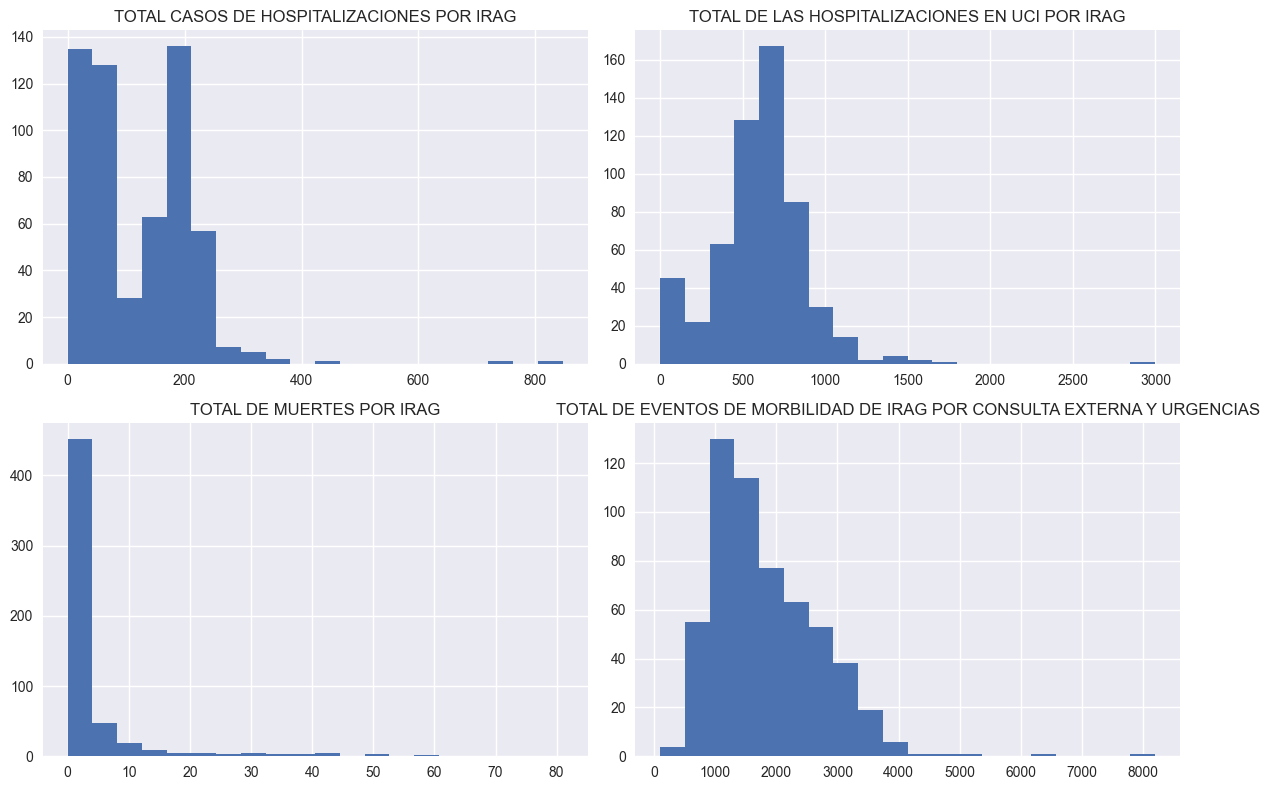

In [53]:
columnas_clave = [
    "TOTAL CASOS DE HOSPITALIZACIONES POR IRAG",
    "TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG",
    "TOTAL DE MUERTES POR IRAG",
    "TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS"
]

df[columnas_clave].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

## 8. Conclusiones del EDA

El dataset presenta una estructura adecuada para modelado supervisado.

- Las variables relacionadas con hospitalizaciones, UCI, mortalidad y consultas muestran patrones coherentes con la dinámica epidemiológica del IRAG.

- La variable objetivo presenta cierto desbalance que deberá considerarse en el modelado.

- Existen relaciones claras entre algunos indicadores, lo cual sugiere posibles redundancias a evaluar durante el modelado.

Este análisis exploratorio proporciona una base sólida para continuar con la preparación de datos y entrenar modelos de clasificación orientados a detectar semanas con comportamiento inusual del IRAG.